# BCG Matrix Profitability Clustering

K-Means clustering untuk mengklasifikasikan produk
ke dalam empat kuadran BCG Matrix berdasarkan dua dimensi utama:
- Sumbu X: volume penjualan (qty_terjual)
- Sumbu Y: margin keuntungan per produk (margin_pct)



## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
import json
import warnings
import os

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

MODEL_DIR = './models'
os.makedirs(MODEL_DIR, exist_ok=True)

print('Library berhasil diimport.')

Library berhasil diimport.



## 2. Load Data

In [2]:
df_transaksi = pd.read_csv('./dataset_bersih/transaksi_bersih.csv', parse_dates=['tanggal'])
df_produk    = pd.read_csv('./dataset_bersih/produk_bersih.csv')

print(f'transaksi_bersih : {len(df_transaksi):,} baris')
print(f'produk_bersih    : {len(df_produk):,} baris')
df_produk.head()

transaksi_bersih : 13,486 baris
produk_bersih    : 120 baris


,id_produk,id_warung,nama_produk,harga_jual,harga_pokok,kategori_produk,status
0,PRD-001-001,WRG-001,Telur 1/4kg,8000,6800,Sembako,Aktif
1,PRD-001-002,WRG-001,Gula Pasir 1kg,17000,14500,Sembako,Aktif
2,PRD-001-003,WRG-001,Rinso 800gr,22000,17500,Kebersihan,Aktif
3,PRD-001-004,WRG-001,Minyak Goreng 2L,34000,29500,Sembako,Aktif
4,PRD-001-005,WRG-001,Sabun Lifebuoy 85gr,5000,3500,Kebersihan,Aktif



## 3. Feature Engineering

In [3]:
# Kalkulasi margin per produk dari tabel produk
df_produk['margin_pct'] = (
    (df_produk['harga_jual'] - df_produk['harga_pokok']) / df_produk['harga_jual'] * 100
).round(2)

print('Distribusi margin_pct:')
print(df_produk['margin_pct'].describe())

Distribusi margin_pct:
count   120.00
mean     20.99
std       8.40
min       8.93
25%      13.64
50%      20.83
75%      26.67
max      42.86
Name: margin_pct, dtype: float64


In [4]:
# Agregasi qty terjual per produk dari tabel transaksi
# Hanya ambil transaksi penjualan (Pemasukan) yang punya id_produk valid
penjualan = df_transaksi[
    (df_transaksi['jenis'] == 'Pemasukan') &
    (df_transaksi['id_produk'].notna()) &
    (df_transaksi['qty'].notna())
].copy()

qty_per_produk = penjualan.groupby('id_produk').agg(
    qty_terjual   = ('qty', 'sum'),
    revenue_total = ('nominal', 'sum'),
    n_transaksi   = ('id_transaksi', 'count')
).reset_index()

print(f'Produk dengan data penjualan: {len(qty_per_produk)}')
qty_per_produk.head()

Produk dengan data penjualan: 113


,id_produk,qty_terjual,revenue_total,n_transaksi
0,PRD-001-001,129.00,1104000.00,84
1,PRD-001-002,115.00,1955000.00,83
2,PRD-001-003,102.00,2244000.00,90
3,PRD-001-004,141.00,4640000.00,97
4,PRD-001-005,83.00,493000.00,75


In [5]:
# Join margin dengan qty_terjual
df_bcg = df_produk[
    df_produk['status'] == 'Aktif'
][['id_produk', 'id_warung', 'nama_produk', 'kategori_produk', 'harga_jual', 'harga_pokok', 'margin_pct']].merge(
    qty_per_produk, on='id_produk', how='inner'
)

# Hapus produk yang tidak pernah terjual
df_bcg = df_bcg[df_bcg['qty_terjual'] > 0].reset_index(drop=True)

print(f'Produk siap untuk clustering: {len(df_bcg)}')
print(f'\nStatistik fitur:')
print(df_bcg[['margin_pct', 'qty_terjual', 'revenue_total']].describe())

Produk siap untuk clustering: 113

Statistik fitur:
       margin_pct  qty_terjual  revenue_total
count      113.00       113.00         113.00
mean        21.09       214.50     2859844.32
std          8.48       130.83     2908867.03
min          8.93        56.00       56000.00
25%         13.89       104.00      990000.00
50%         20.83       170.00     1892000.00
75%         26.67       292.00     3874000.00
max         42.86       548.00    19173000.00



## 4. Preprocessing

In [6]:
# Fitur untuk clustering: margin_pct dan qty_terjual
# qty_terjual dilog-transform untuk mengurangi skewness
df_bcg['log_qty'] = np.log1p(df_bcg['qty_terjual'])

features = ['margin_pct', 'log_qty']
X = df_bcg[features].values

# Standardisasi agar skala tidak mendominasi
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Fitur sebelum scaling:')
print(pd.DataFrame(X, columns=features).describe())
print('\nFitur setelah scaling (mean ~0, std ~1):')
print(pd.DataFrame(X_scaled, columns=features).describe())

Fitur sebelum scaling:
       margin_pct  log_qty
count      113.00   113.00
mean        21.09     5.19
std          8.48     0.61
min          8.93     4.04
25%         13.89     4.65
50%         20.83     5.14
75%         26.67     5.68
max         42.86     6.31

Fitur setelah scaling (mean ~0, std ~1):
       margin_pct  log_qty
count      113.00   113.00
mean         0.00     0.00
std          1.00     1.00
min         -1.44    -1.90
25%         -0.85    -0.89
50%         -0.03    -0.08
75%          0.66     0.81
max          2.58     1.85



## 5. Menentukan Jumlah Cluster Optimal

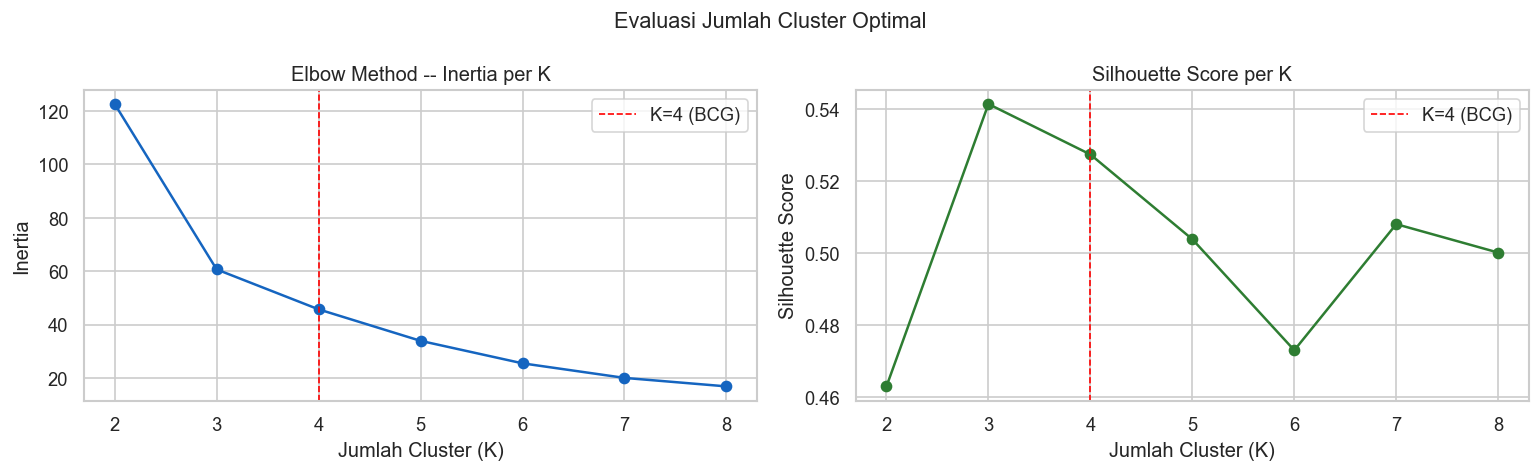

Silhouette scores:
  K=2: 0.4631
  K=3: 0.5414
  K=4: 0.5274
  K=5: 0.5039
  K=6: 0.4731
  K=7: 0.5081
  K=8: 0.5002


In [7]:
# Elbow Method
inertia_list = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia_list.append(km.inertia_)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(k_range, inertia_list, marker='o', color='#1565C0')
axes[0].set_title('Elbow Method -- Inertia per K', fontsize=12)
axes[0].set_xlabel('Jumlah Cluster (K)')
axes[0].set_ylabel('Inertia')
axes[0].axvline(x=4, color='red', linestyle='--', linewidth=1, label='K=4 (BCG)')
axes[0].legend()

# Silhouette Score
sil_scores = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

axes[1].plot(k_range, sil_scores, marker='o', color='#2E7D32')
axes[1].set_title('Silhouette Score per K', fontsize=12)
axes[1].set_xlabel('Jumlah Cluster (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].axvline(x=4, color='red', linestyle='--', linewidth=1, label='K=4 (BCG)')
axes[1].legend()

plt.suptitle('Evaluasi Jumlah Cluster Optimal', fontsize=13)
plt.tight_layout()
plt.show()

print('Silhouette scores:')
for k, s in zip(k_range, sil_scores):
    print(f'  K={k}: {s:.4f}')


## 6. Training K-Means (K=4)

In [9]:
# K=4 sesuai definisi BCG Matrix: Star, Cash Cow, Question Mark, Dog
K = 4
kmeans = KMeans(n_clusters=K, random_state=42, n_init=20, max_iter=300)
df_bcg['cluster'] = kmeans.fit_predict(X_scaled)

# Evaluasi model
sil  = silhouette_score(X_scaled, df_bcg['cluster'])
db   = davies_bouldin_score(X_scaled, df_bcg['cluster'])
print(f'Silhouette Score  : {sil:.4f}')
print(f'Davies-Bouldin    : {db:.4f}  (makin rendah makin baik)')
print(f'Inertia           : {kmeans.inertia_:.2f}')
print(f'\nDistribusi produk per cluster:')
print(df_bcg['cluster'].value_counts().sort_index())

Silhouette Score  : 0.5274
Davies-Bouldin    : 0.6195  (makin rendah makin baik)
Inertia           : 45.69

Distribusi produk per cluster:
cluster
0     9
1    43
2    46
3    15
Name: count, dtype: int64



## 7. Mapping Cluster ke Kuadran BCG

In [10]:
# Tentukan kuadran berdasarkan rata-rata margin dan qty per cluster
cluster_summary = df_bcg.groupby('cluster').agg(
    mean_margin = ('margin_pct', 'mean'),
    mean_qty    = ('qty_terjual', 'mean'),
    n_produk    = ('id_produk', 'count')
).reset_index()

print('Rata-rata fitur per cluster:')
print(cluster_summary)

# Median sebagai threshold pemisah kuadran
median_margin = df_bcg['margin_pct'].median()
median_qty    = df_bcg['qty_terjual'].median()
print(f'\nMedian margin : {median_margin:.2f}%')
print(f'Median qty    : {median_qty:.0f} unit')

Rata-rata fitur per cluster:
   cluster  mean_margin  mean_qty  n_produk
0        0        39.37    114.33         9
1        1        24.52    355.58        43
2        2        13.01    142.11        46
3        3        25.09     92.20        15

Median margin : 20.83%
Median qty    : 170 unit


In [11]:
# Mapping otomatis berdasarkan posisi centroid terhadap median
def assign_quadrant(row, med_margin, med_qty):
    high_margin = row['mean_margin'] >= med_margin
    high_qty    = row['mean_qty']    >= med_qty
    if high_margin and high_qty:
        return 'Star'
    elif high_margin and not high_qty:
        return 'Cash Cow'
    elif not high_margin and high_qty:
        return 'Question Mark'
    else:
        return 'Dog'

cluster_summary['kuadran'] = cluster_summary.apply(
    assign_quadrant, axis=1, med_margin=median_margin, med_qty=median_qty
)

# Rekomendasi per kuadran
rekomendasi_map = {
    'Star':          'Pertahankan stok, prioritaskan display dan promosi.',
    'Cash Cow':      'Tingkatkan promosi untuk mendorong volume penjualan.',
    'Question Mark': 'Evaluasi harga pokok atau pertimbangkan naikkan harga jual.',
    'Dog':           'Pertimbangkan kurangi stok atau hapus dari katalog.',
}
cluster_summary['rekomendasi'] = cluster_summary['kuadran'].map(rekomendasi_map)

# Merge kembali ke df_bcg
kuadran_map = cluster_summary.set_index('cluster')['kuadran'].to_dict()
df_bcg['kuadran']     = df_bcg['cluster'].map(kuadran_map)
df_bcg['rekomendasi'] = df_bcg['kuadran'].map(rekomendasi_map)

print('Mapping cluster ke kuadran BCG:')
print(cluster_summary[['cluster', 'mean_margin', 'mean_qty', 'kuadran', 'rekomendasi']].to_string(index=False))

Mapping cluster ke kuadran BCG:
 cluster  mean_margin  mean_qty  kuadran                                          rekomendasi
       0        39.37    114.33 Cash Cow Tingkatkan promosi untuk mendorong volume penjualan.
       1        24.52    355.58     Star  Pertahankan stok, prioritaskan display dan promosi.
       2        13.01    142.11      Dog  Pertimbangkan kurangi stok atau hapus dari katalog.
       3        25.09     92.20 Cash Cow Tingkatkan promosi untuk mendorong volume penjualan.



## 8. Visualisasi BCG Matrix

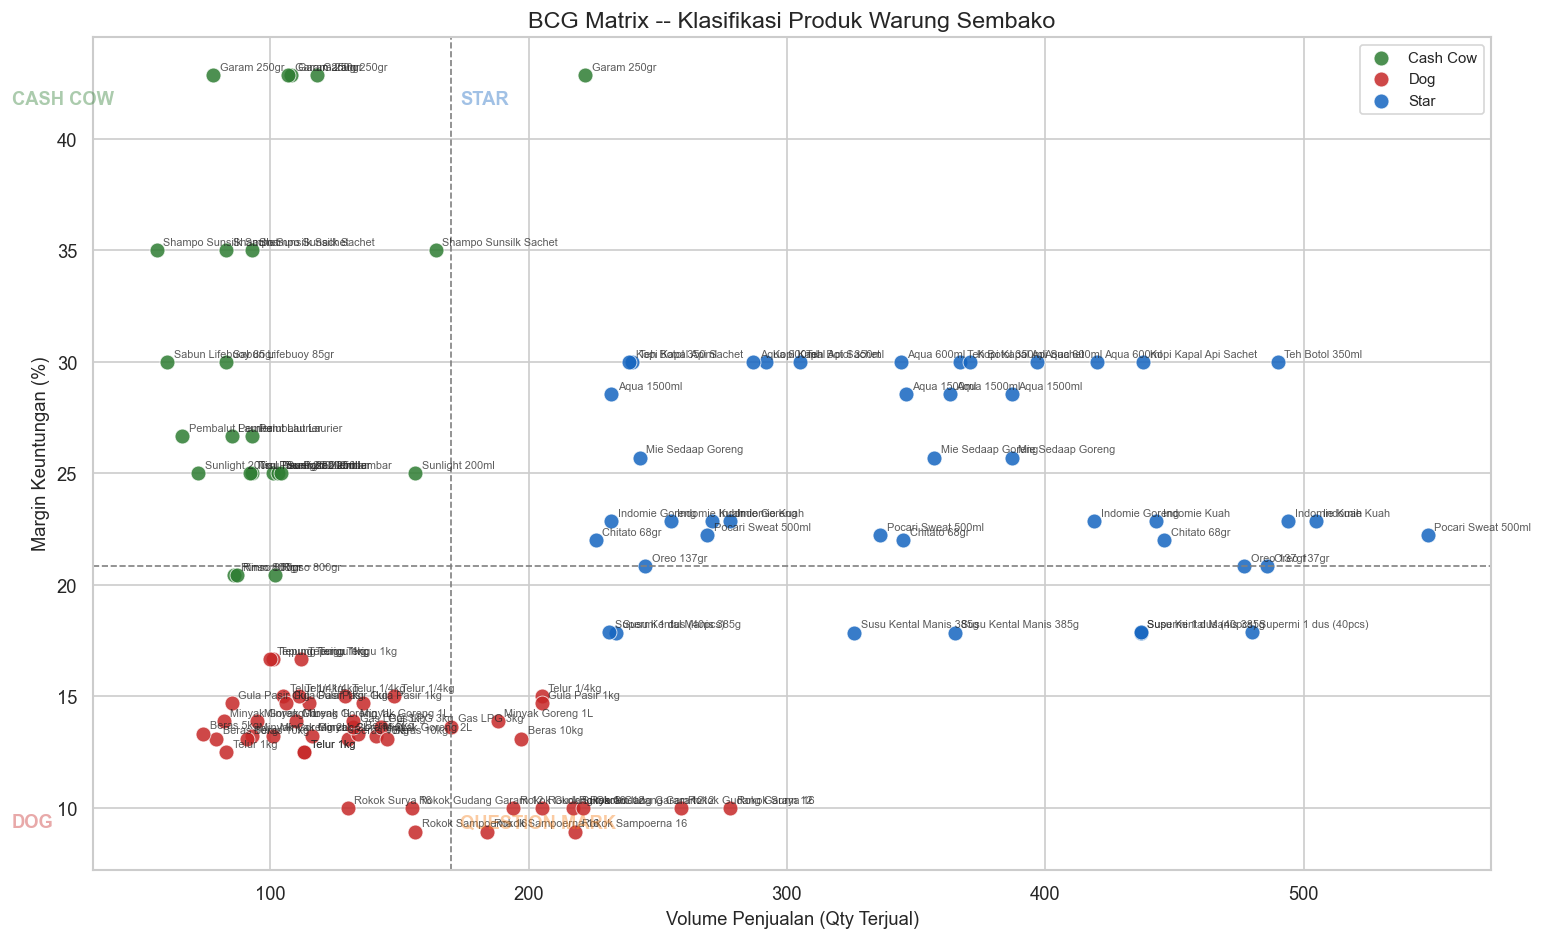

In [12]:
color_map = {
    'Star':          '#1565C0',
    'Cash Cow':      '#2E7D32',
    'Question Mark': '#F57F17',
    'Dog':           '#C62828',
}

fig, ax = plt.subplots(figsize=(13, 8))

for kuadran, grp in df_bcg.groupby('kuadran'):
    ax.scatter(
        grp['qty_terjual'], grp['margin_pct'],
        label=kuadran, color=color_map[kuadran],
        s=80, alpha=0.85, edgecolors='white', linewidths=0.5
    )

# Garis median sebagai pembatas kuadran
ax.axvline(x=median_qty,    color='gray', linestyle='--', linewidth=1)
ax.axhline(y=median_margin, color='gray', linestyle='--', linewidth=1)

# Label produk
for _, row in df_bcg.iterrows():
    ax.annotate(
        row['nama_produk'],
        (row['qty_terjual'], row['margin_pct']),
        fontsize=6.5, alpha=0.75,
        xytext=(4, 3), textcoords='offset points'
    )

# Label kuadran di pojok
xmax = df_bcg['qty_terjual'].max()
ymax = df_bcg['margin_pct'].max()
ymin = df_bcg['margin_pct'].min()
ax.text(median_qty * 1.02, ymax * 0.97, 'STAR', fontsize=11, color='#1565C0', fontweight='bold', alpha=0.4)
ax.text(0, ymax * 0.97, 'CASH COW', fontsize=11, color='#2E7D32', fontweight='bold', alpha=0.4)
ax.text(median_qty * 1.02, ymin * 1.02, 'QUESTION MARK', fontsize=11, color='#F57F17', fontweight='bold', alpha=0.4)
ax.text(0, ymin * 1.02, 'DOG', fontsize=11, color='#C62828', fontweight='bold', alpha=0.4)

ax.set_title('BCG Matrix -- Klasifikasi Produk Warung Sembako', fontsize=14)
ax.set_xlabel('Volume Penjualan (Qty Terjual)', fontsize=11)
ax.set_ylabel('Margin Keuntungan (%)', fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/bcg_matrix_plot.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Ringkasan per kuadran
ringkasan = df_bcg.groupby('kuadran').agg(
    jumlah_produk   = ('id_produk', 'count'),
    rata_margin     = ('margin_pct', 'mean'),
    rata_qty        = ('qty_terjual', 'mean'),
    total_revenue   = ('revenue_total', 'sum')
).round(2)

print(ringkasan)


for kuadran in ['Star', 'Cash Cow', 'Question Mark', 'Dog']:
    produk_list = df_bcg[df_bcg['kuadran'] == kuadran]['nama_produk'].tolist()
    print(f'  {kuadran}: {produk_list}')

Ringkasan per kuadran BCG:
          jumlah_produk  rata_margin  rata_qty  total_revenue
kuadran                                                      
Cash Cow             24        30.44    100.50    18882500.00
Dog                  46        13.01    142.11   171535908.00
Star                 43        24.52    355.58   132744000.00

Daftar produk per kuadran:
  Star: ['Teh Botol 350ml', 'Pocari Sweat 500ml', 'Oreo 137gr', 'Kopi Kapal Api Sachet', 'Indomie Kuah', 'Supermi 1 dus (40pcs)', 'Kopi Kapal Api Sachet', 'Mie Sedaap Goreng', 'Indomie Goreng', 'Susu Kental Manis 385g', 'Chitato 68gr', 'Teh Botol 350ml', 'Indomie Kuah', 'Aqua 1500ml', 'Aqua 600ml', 'Aqua 1500ml', 'Aqua 600ml', 'Susu Kental Manis 385g', 'Oreo 137gr', 'Chitato 68gr', 'Teh Botol 350ml', 'Supermi 1 dus (40pcs)', 'Indomie Kuah', 'Mie Sedaap Goreng', 'Indomie Goreng', 'Pocari Sweat 500ml', 'Susu Kental Manis 385g', 'Aqua 600ml', 'Kopi Kapal Api Sachet', 'Aqua 1500ml', 'Indomie Kuah', 'Susu Kental Manis 385g', 'Indomi


## 9. Evaluasi Model

In [ ]:
print('==== EVALUASI MODEL K-MEANS BCG MATRIX ====')
print(f'Silhouette Score  : {sil:.4f}')
print(f'Davies-Bouldin    : {db:.4f}')
print(f'Inertia           : {kmeans.inertia_:.2f}')
print()

print()
print('Distribusi produk per kuadran:')
print(df_bcg['kuadran'].value_counts())

==== EVALUASI MODEL K-MEANS BCG MATRIX ====
Silhouette Score  : 0.5274
Davies-Bouldin    : 0.6195
Inertia           : 45.69

Silhouette Score >= 0.5: cluster terpisah dengan baik.

Distribusi produk per kuadran:
kuadran
Dog         46
Star        43
Cash Cow    24
Name: count, dtype: int64



## 10. Export Model dan Hasil

In [15]:
# Simpan model dan scaler
joblib.dump(kmeans,  f'{MODEL_DIR}/kmeans_bcg.pkl')
joblib.dump(scaler,  f'{MODEL_DIR}/scaler_bcg.pkl')

# Simpan mapping cluster ke kuadran
mapping = cluster_summary[['cluster', 'kuadran', 'rekomendasi']].set_index('cluster').to_dict('index')
with open(f'{MODEL_DIR}/bcg_cluster_mapping.json', 'w') as f:
    json.dump(mapping, f, indent=2)

# Simpan hasil klasifikasi produk
df_bcg[['id_produk', 'id_warung', 'nama_produk', 'kategori_produk',
        'margin_pct', 'qty_terjual', 'revenue_total',
        'cluster', 'kuadran', 'rekomendasi']].to_csv(
    f'{MODEL_DIR}/bcg_hasil_klasifikasi.csv', index=False
)

print('Model dan hasil berhasil disimpan:')
print(f'  {MODEL_DIR}/kmeans_bcg.pkl')
print(f'  {MODEL_DIR}/scaler_bcg.pkl')
print(f'  {MODEL_DIR}/bcg_cluster_mapping.json')
print(f'  {MODEL_DIR}/bcg_hasil_klasifikasi.csv')

Model dan hasil berhasil disimpan:
  ./models/kmeans_bcg.pkl
  ./models/scaler_bcg.pkl
  ./models/bcg_cluster_mapping.json
  ./models/bcg_hasil_klasifikasi.csv



## 11. Inference Function 

In [ ]:
def predict_bcg(produk_list: list, model_dir: str = './models') -> list:
    """
    Inference function untuk BCG Matrix.

    Parameters
    ----------
    produk_list : list of dict
        Setiap dict harus berisi:
        - id_produk    : str
        - nama_produk  : str
        - margin_pct   : float  ( (harga_jual - harga_pokok) / harga_jual * 100)
        - qty_terjual  : int    (total qty terjual dalam periode)

    Returns
    -------
    list of dict
        Setiap dict berisi id_produk, nama_produk, cluster, kuadran, rekomendasi
    """
    kmeans_loaded  = joblib.load(f'{model_dir}/kmeans_bcg.pkl')
    scaler_loaded  = joblib.load(f'{model_dir}/scaler_bcg.pkl')
    with open(f'{model_dir}/bcg_cluster_mapping.json') as f:
        mapping_loaded = json.load(f)

    df_input = pd.DataFrame(produk_list)
    df_input['log_qty'] = np.log1p(df_input['qty_terjual'])

    X_input  = df_input[['margin_pct', 'log_qty']].values
    X_scaled = scaler_loaded.transform(X_input)
    clusters = kmeans_loaded.predict(X_scaled)

    hasil = []
    for i, row in df_input.iterrows():
        cluster_id = str(clusters[i])
        info = mapping_loaded.get(cluster_id, {})
        hasil.append({
            'id_produk':    row['id_produk'],
            'nama_produk':  row['nama_produk'],
            'margin_pct':   row['margin_pct'],
            'qty_terjual':  row['qty_terjual'],
            'cluster':      int(clusters[i]),
            'kuadran':      info.get('kuadran', 'Unknown'),
            'rekomendasi':  info.get('rekomendasi', '-'),
        })
    return hasil


# Test inference
test_input = [
    {'id_produk': 'PRD-TEST-001', 'nama_produk': 'Indomie Goreng', 'margin_pct': 22.9, 'qty_terjual': 850},
    {'id_produk': 'PRD-TEST-002', 'nama_produk': 'Beras 10kg',     'margin_pct': 13.1, 'qty_terjual': 120},
    {'id_produk': 'PRD-TEST-003', 'nama_produk': 'Sabun Mandi',    'margin_pct': 30.0, 'qty_terjual': 45},
    {'id_produk': 'PRD-TEST-004', 'nama_produk': 'Rokok GG',       'margin_pct': 10.0, 'qty_terjual': 30},
]

hasil_test = predict_bcg(test_input)
print('Hasil inference test:')
for h in hasil_test:
    print(f"  {h['nama_produk']:25s} -> {h['kuadran']:15s} | {h['rekomendasi']}")

Hasil inference test:
  Indomie Goreng            -> Star            | Pertahankan stok, prioritaskan display dan promosi.
  Beras 10kg                -> Dog             | Pertimbangkan kurangi stok atau hapus dari katalog.
  Sabun Mandi               -> Cash Cow        | Tingkatkan promosi untuk mendorong volume penjualan.
  Rokok GG                  -> Dog             | Pertimbangkan kurangi stok atau hapus dari katalog.
